<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/LSTM_Base_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller en clase: 20/10/2025**

#**Base de datos: wheather_feature - variable de interes: wind_speed**
#Julian David Morales Pineda

#**Notebook — LSTM con datos reales**

#**Librerias y base de datos**

In [1]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('wheather_feature.txt')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'wheather_feature.txt' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [2]:
wind_speed_data = df['wind_speed']
display(wind_speed_data.head())

,wind_speed
0,1
1,1
2,0
3,0
4,0


#**Celda 1: Parámetros globales**

In [3]:
# ===== Celda 1: Parámetros globales =====
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.signal import periodogram, welch, butter, filtfilt, detrend
import pandas as pd
import random
import os

# -------- Parámetros controlables --------
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 1e-4
SEQ_LENGTH = 512            # longitud de cada ventana
FS = 200.0                  # frecuencia de muestreo (Hz)
OVERLAP = int(SEQ_LENGTH * 0.9)  # 90% de solapamiento
TARGET_SAMPLES = 10000      # objetivo: ~10,000 ventanas

# Filtro pasa-altas (para eliminar fuga DC)
HP_CUTOFF = 0.5
HP_ORDER = 4

# reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"Configuración:\n  EPOCHS={EPOCHS}\n  BATCH_SIZE={BATCH_SIZE}\n  SEQ_LENGTH={SEQ_LENGTH}\n  FS={FS}\n  OVERLAP={OVERLAP}\n  TARGET_SAMPLES={TARGET_SAMPLES}")


Configuración:
  EPOCHS=150
  BATCH_SIZE=64
  SEQ_LENGTH=512
  FS=200.0
  OVERLAP=460
  TARGET_SAMPLES=10000


#**Celda 2: Generación / carga y preprocesamiento de datos + PSDs (Welch y Periodogram)**

/tmp/ipython-input-3405012067.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wind = wind.fillna(method='bfill').fillna(method='ffill')


✅ Muestras generadas: 3421 (solo datos reales)
Shape: X=(3421, 512), Y=(3421, 257)


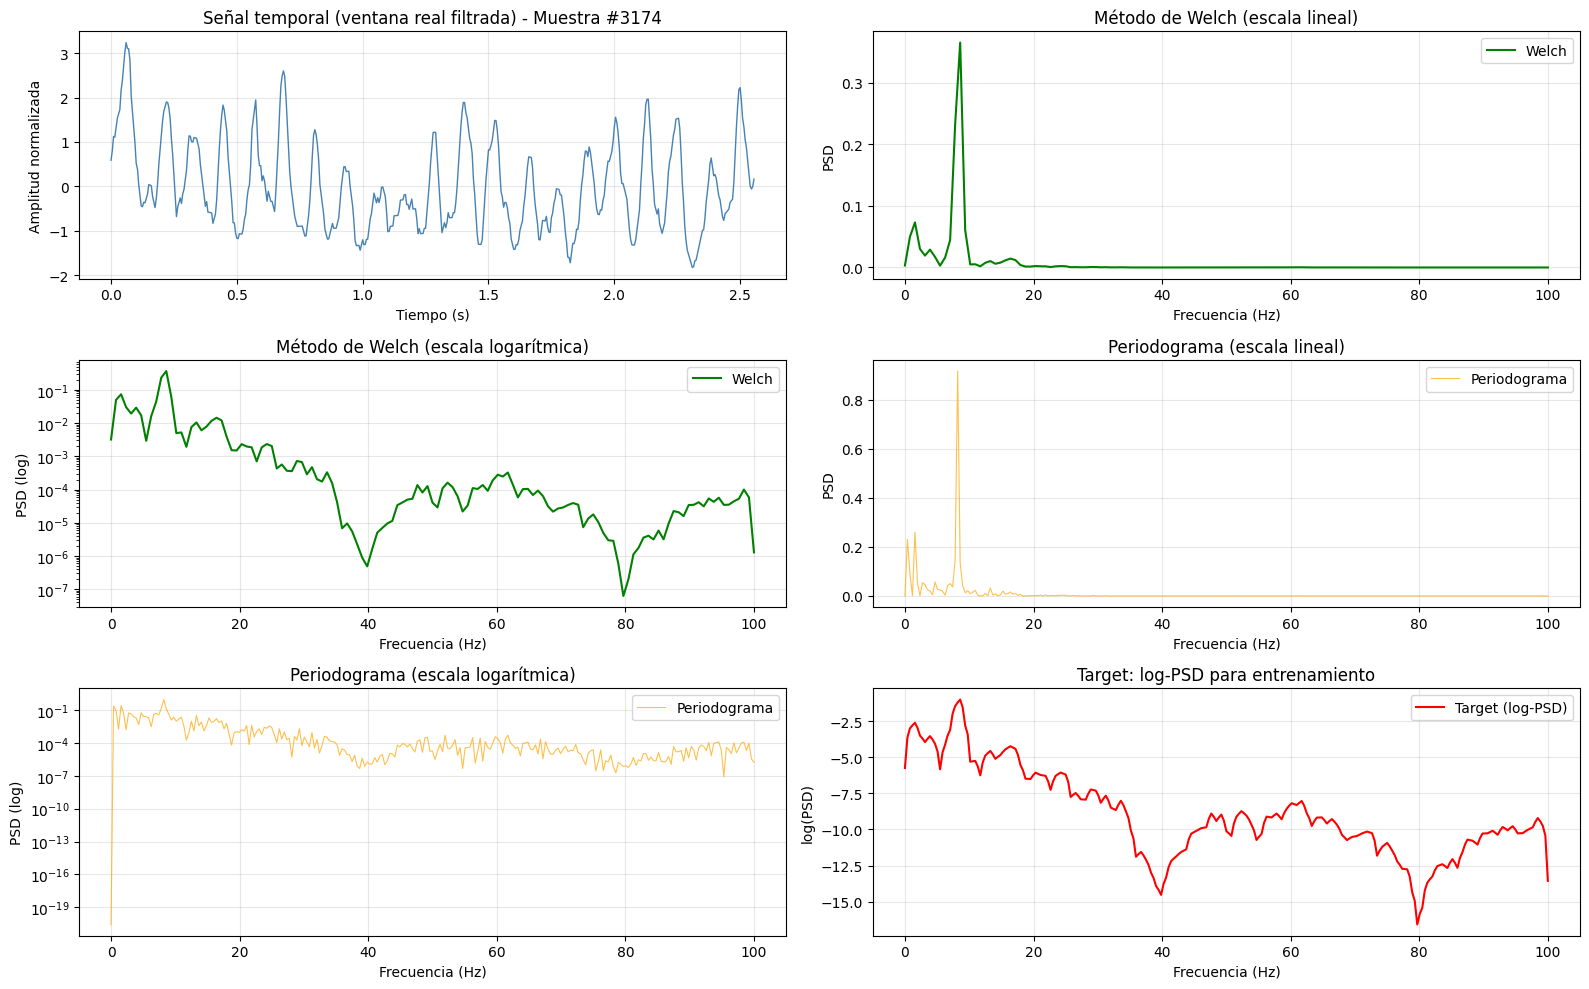

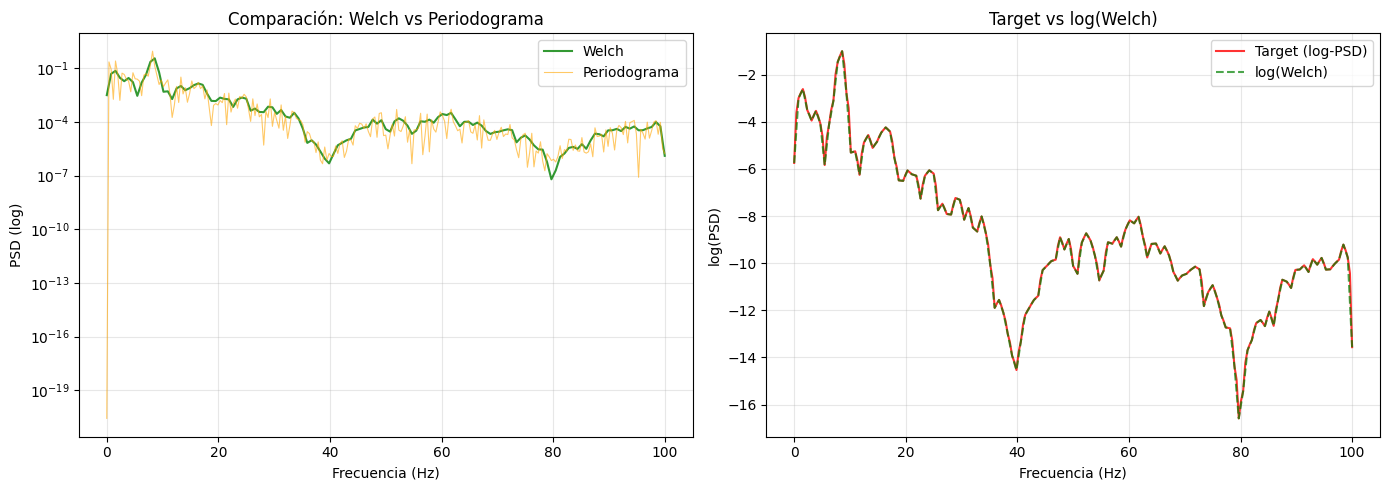


📊 Información de la muestra visualizada:
   - Índice: 3174
   - Forma de X: (512,)
   - Forma de Y (target): (257,)
   - Rango de frecuencias Welch: 0.00 - 100.00 Hz
   - Rango de frecuencias Periodograma: 0.00 - 100.00 Hz
   - Rango de frecuencias Target: 0.00 - 100.00 Hz


In [4]:
# ===== Celda 2: Carga y preprocesamiento =====

if not os.path.exists("wheather_feature.txt"):
    raise FileNotFoundError("❌ No se encontró 'wheather_feature.txt'.")

df = pd.read_csv("wheather_feature.txt", sep=",", comment="#", na_values=["NaN", ""])
if "wind_speed" not in df.columns:
    raise ValueError("❌ No se encontró la columna 'wind_speed' en el archivo.")

wind = df["wind_speed"].replace([np.inf, -np.inf], np.nan)
wind = wind.interpolate(method='linear', limit_direction='both')
wind = wind.fillna(method='bfill').fillna(method='ffill')

# eliminar outliers extremos
q1, q3 = wind.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 3*iqr, q3 + 3*iqr
wind = np.clip(wind, low, high)

# suavizado y normalización global
wind = pd.Series(wind).rolling(window=5, center=True, min_periods=1).mean().to_numpy(dtype=np.float32)
wind = (wind - np.mean(wind)) / (np.std(wind) + 1e-12)

# filtro pasa-altas para eliminar fuga DC
def highpass_filter(signal, fs, cutoff=HP_CUTOFF, order=HP_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, signal)

# extracción de ventanas
segments = []
step = SEQ_LENGTH - OVERLAP
for start in range(0, len(wind) - SEQ_LENGTH, step):
    seg = wind[start:start+SEQ_LENGTH]
    seg = detrend(seg)
    seg = highpass_filter(seg, FS)
    seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-12)
    segments.append(seg.astype(np.float32))
    if len(segments) >= TARGET_SAMPLES:
        break

X = np.vstack(segments)
PSD_LEN = SEQ_LENGTH//2 + 1
EPS = 1e-12

# Cálculo de PSD real con Welch
Y = []
freqs_welch = None
for s in X:
    f_w, Pxx_w = welch(s, fs=FS, nperseg=256)
    if freqs_welch is None:
        freqs_welch = f_w
    if len(Pxx_w) != PSD_LEN:
        Pxx_w = np.interp(np.linspace(0, len(Pxx_w)-1, PSD_LEN),
                          np.arange(len(Pxx_w)), Pxx_w)
    Y.append(np.log(Pxx_w + EPS))

Y = np.vstack(Y).astype(np.float32)

print(f"✅ Muestras generadas: {len(X)} (solo datos reales)")
print(f"Shape: X={X.shape}, Y={Y.shape}")

# ===== VISUALIZACIÓN COMPLETA =====
idx = np.random.randint(0, len(X))
sig = X[idx]
target_psd = Y[idx]

# Calcular Welch y Periodograma
f_welch, Pxx_welch = welch(sig, fs=FS, nperseg=256)
f_periodo, Pxx_periodo = periodogram(sig, fs=FS)

# Crear frecuencias para el target (debe coincidir con PSD_LEN)
f_target = np.linspace(0, FS/2, PSD_LEN)

plt.figure(figsize=(16, 10))

# 1. Señal temporal
plt.subplot(3, 2, 1)
t = np.arange(SEQ_LENGTH) / FS
plt.plot(t, sig, linewidth=1, color='steelblue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud normalizada')
plt.title(f'Señal temporal (ventana real filtrada) - Muestra #{idx}')
plt.grid(True, alpha=0.3)

# 2. Welch (escala lineal)
plt.subplot(3, 2, 2)
plt.plot(f_welch, Pxx_welch, linewidth=1.5, color='green', label='Welch')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title('Método de Welch (escala lineal)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Welch (escala log)
plt.subplot(3, 2, 3)
plt.semilogy(f_welch, Pxx_welch, linewidth=1.5, color='green', label='Welch')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (log)')
plt.title('Método de Welch (escala logarítmica)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Periodograma (escala lineal)
plt.subplot(3, 2, 4)
plt.plot(f_periodo, Pxx_periodo, linewidth=0.8, color='orange', alpha=0.7, label='Periodograma')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title('Periodograma (escala lineal)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Periodograma (escala log)
plt.subplot(3, 2, 5)
plt.semilogy(f_periodo, Pxx_periodo, linewidth=0.8, color='orange', alpha=0.7, label='Periodograma')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (log)')
plt.title('Periodograma (escala logarítmica)')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Target (log-PSD esperado)
plt.subplot(3, 2, 6)
plt.plot(f_target, target_psd, linewidth=1.5, color='red', label='Target (log-PSD)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('log(PSD)')
plt.title('Target: log-PSD para entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== COMPARACIÓN DIRECTA =====
plt.figure(figsize=(14, 5))

# Comparación en escala logarítmica
plt.subplot(1, 2, 1)
plt.semilogy(f_welch, Pxx_welch, linewidth=1.5, color='green', label='Welch', alpha=0.8)
plt.semilogy(f_periodo, Pxx_periodo, linewidth=0.8, color='orange', label='Periodograma', alpha=0.6)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (log)')
plt.title('Comparación: Welch vs Periodograma')
plt.legend()
plt.grid(True, alpha=0.3)

# Target vs Welch log
plt.subplot(1, 2, 2)
plt.plot(f_target, target_psd, linewidth=1.5, color='red', label='Target (log-PSD)', alpha=0.8)
plt.plot(f_welch, np.log(Pxx_welch + EPS), linewidth=1.5, color='green',
         label='log(Welch)', linestyle='--', alpha=0.7)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('log(PSD)')
plt.title('Target vs log(Welch)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Información de la muestra visualizada:")
print(f"   - Índice: {idx}")
print(f"   - Forma de X: {sig.shape}")
print(f"   - Forma de Y (target): {target_psd.shape}")
print(f"   - Rango de frecuencias Welch: {f_welch[0]:.2f} - {f_welch[-1]:.2f} Hz")
print(f"   - Rango de frecuencias Periodograma: {f_periodo[0]:.2f} - {f_periodo[-1]:.2f} Hz")
print(f"   - Rango de frecuencias Target: {f_target[0]:.2f} - {f_target[-1]:.2f} Hz")

#**Celda 3 – División del dataset y creación de DataLoaders**

In [5]:
# ===== Celda 3: Split y DataLoaders =====
X_tensor = torch.from_numpy(X).unsqueeze(-1)   # (N, seq_len, 1)
Y_tensor = torch.from_numpy(Y)

N_total = len(X_tensor)
train_n = int(0.6 * N_total)
val_n = int(0.2 * N_total)
test_n = N_total - train_n - val_n

dataset = TensorDataset(X_tensor, Y_tensor)
train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n],
                                         generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"🔹 Split -> Train: {train_n}, Val: {val_n}, Test: {test_n}")


🔹 Split -> Train: 2052, Val: 684, Test: 685


#**Celda 4 – Definición y entrenamiento del modelo LSTM**

🧠 Dispositivo usado: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Epoch 001/150  Train MSE=8.263201e+01  Val MSE=8.215679e+01
Epoch 002/150  Train MSE=8.215049e+01  Val MSE=8.154140e+01
Epoch 003/150  Train MSE=8.122576e+01  Val MSE=8.001500e+01
Epoch 004/150  Train MSE=7.761332e+01  Val MSE=7.125284e+01
Epoch 005/150  Train MSE=6.259989e+01  Val MSE=5.219250e+01
Epoch 006/150  Train MSE=4.355078e+01  Val MSE=3.369500e+01
Epoch 007/150  Train MSE=2.625839e+01  Val MSE=1.822915e+01
Epoch 008/150  Train MSE=1.298396e+01  Val MSE=7.662220e+00
Epoch 009/150  Train MSE=5.048073e+00  Val MSE=2.438258e+00
Epoch 010/150  Train MSE=1.906458e+00  Val MSE=1.144245e+00
Epoch 011/150  Train MSE=1.297177e+00  Val MSE=9.138199e-01
Epoch 012/150  Train MSE=1.169589e+00  Val MSE=8.526197e-01
Epoch 013/150  Train MSE=1.140501e+00  Val MSE=8.322243e-01
Epoch 014/150  Train MSE=1.107756e+00  Val MSE=8.249226e-01
Epoch 015/150  Train MSE=1.106183e+00  Val MSE=8.219881e-01
Epoch 016/150  Train MSE=1.105795e+00  Val MSE=8.212512e-01
Epoch 017/150  Train MSE=1.097129e+00  V

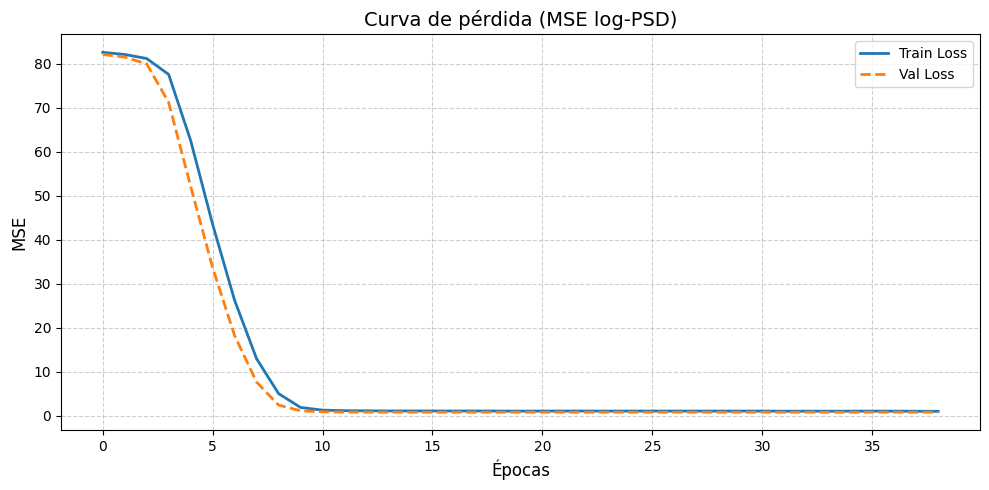

In [6]:
# ===== Celda 4: Modelo LSTM y entrenamiento (versión corregida y optimizada) =====

class LSTM_PSD(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=None, dropout=0.1, bidir=False):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=bidir)
        mult = 2 if bidir else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * mult, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]         # solo la última salida de la secuencia
        return self.fc(out)

# -----------------------------------------------------------------------------
# Preparación del modelo y parámetros de entrenamiento
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧠 Dispositivo usado:", device)

PSD_LEN = Y.shape[1]  # tamaño de salida (de la celda 2)
model = LSTM_PSD(input_size=1, hidden_size=64, num_layers=1,
                 output_size=PSD_LEN, dropout=0.1, bidir=False).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# -----------------------------------------------------------------------------
# Entrenamiento con Early Stopping y clipping de gradiente
# -----------------------------------------------------------------------------
best_val, patience, counter = float('inf'), 15, 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Entrenamiento ---
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # --- Validación ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d}/{EPOCHS}  Train MSE={train_loss:.6e}  Val MSE={val_loss:.6e}")

    # --- Early Stopping ---
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹ Early stopping activado (mejor val={best_val:.6e})")
            break

# restaurar el mejor modelo
model.load_state_dict(best_state)

# -----------------------------------------------------------------------------
# Visualización de pérdidas
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2, linestyle='--')
plt.title('Curva de pérdida (MSE log-PSD)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#**Celda 5 – Evaluación y visualización final**

📊 Test MSE (log-PSD): 7.728881e-01


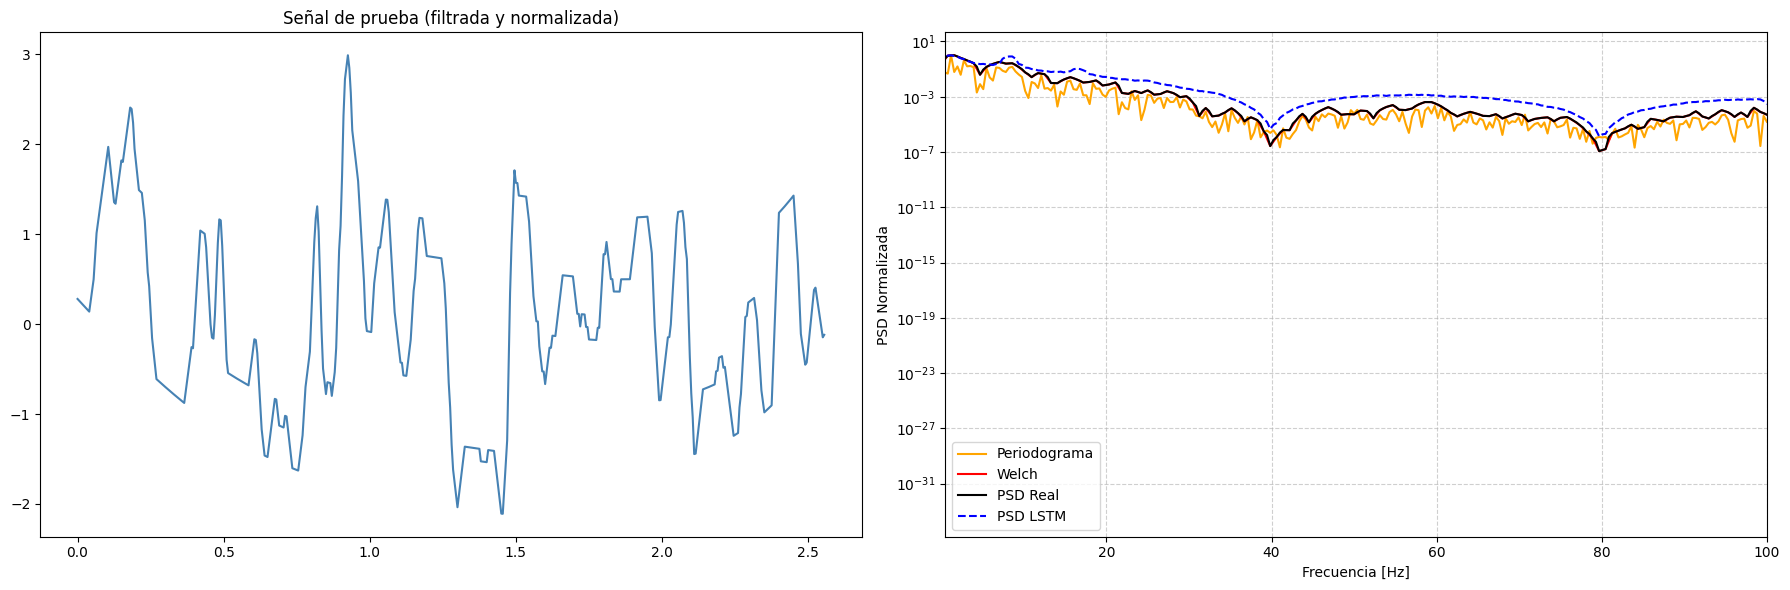

In [7]:
# ===== Celda 5: Evaluación final =====
model.eval()
test_loss, preds, trues, inputs = 0.0, [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        test_loss += loss.item() * xb.size(0)
        preds.append(y_pred.cpu().numpy())
        trues.append(yb.cpu().numpy())
        inputs.append(xb.cpu().numpy())

test_loss /= len(test_loader.dataset)
preds = np.vstack(preds)
trues = np.vstack(trues)
inputs = np.vstack(inputs)

print(f"📊 Test MSE (log-PSD): {test_loss:.6e}")

# convertir a PSD lineal
preds_lin = np.exp(preds)
trues_lin = np.exp(trues)

# graficar ejemplo
idx = np.random.randint(0, len(preds_lin))
signal = detrend(inputs[idx].squeeze())
signal = highpass_filter(signal, FS)

f_w, Pxx_w = welch(signal, fs=FS, nperseg=256)
f_p, Pxx_p = periodogram(signal, fs=FS)
f_model = np.linspace(0, FS/2, preds_lin.shape[1])

def norm(x): return x / (np.max(x) + 1e-12)
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.plot(np.arange(SEQ_LENGTH)/FS, signal, color='steelblue')
plt.title("Señal de prueba (filtrada y normalizada)")
plt.subplot(1,2,2)
plt.semilogy(f_p, norm(Pxx_p), label='Periodograma', color='orange')
plt.semilogy(f_w, norm(Pxx_w), label='Welch', color='red')
plt.semilogy(f_model, norm(trues_lin[idx]), label='PSD Real', color='black')
plt.semilogy(f_model, norm(preds_lin[idx]), '--', label='PSD LSTM', color='blue')
plt.xlim(0.5, FS/2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD Normalizada")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#**Celda 6 — Evaluación múltiple (Welch, Periodograma y error espectral promedio en dB)**

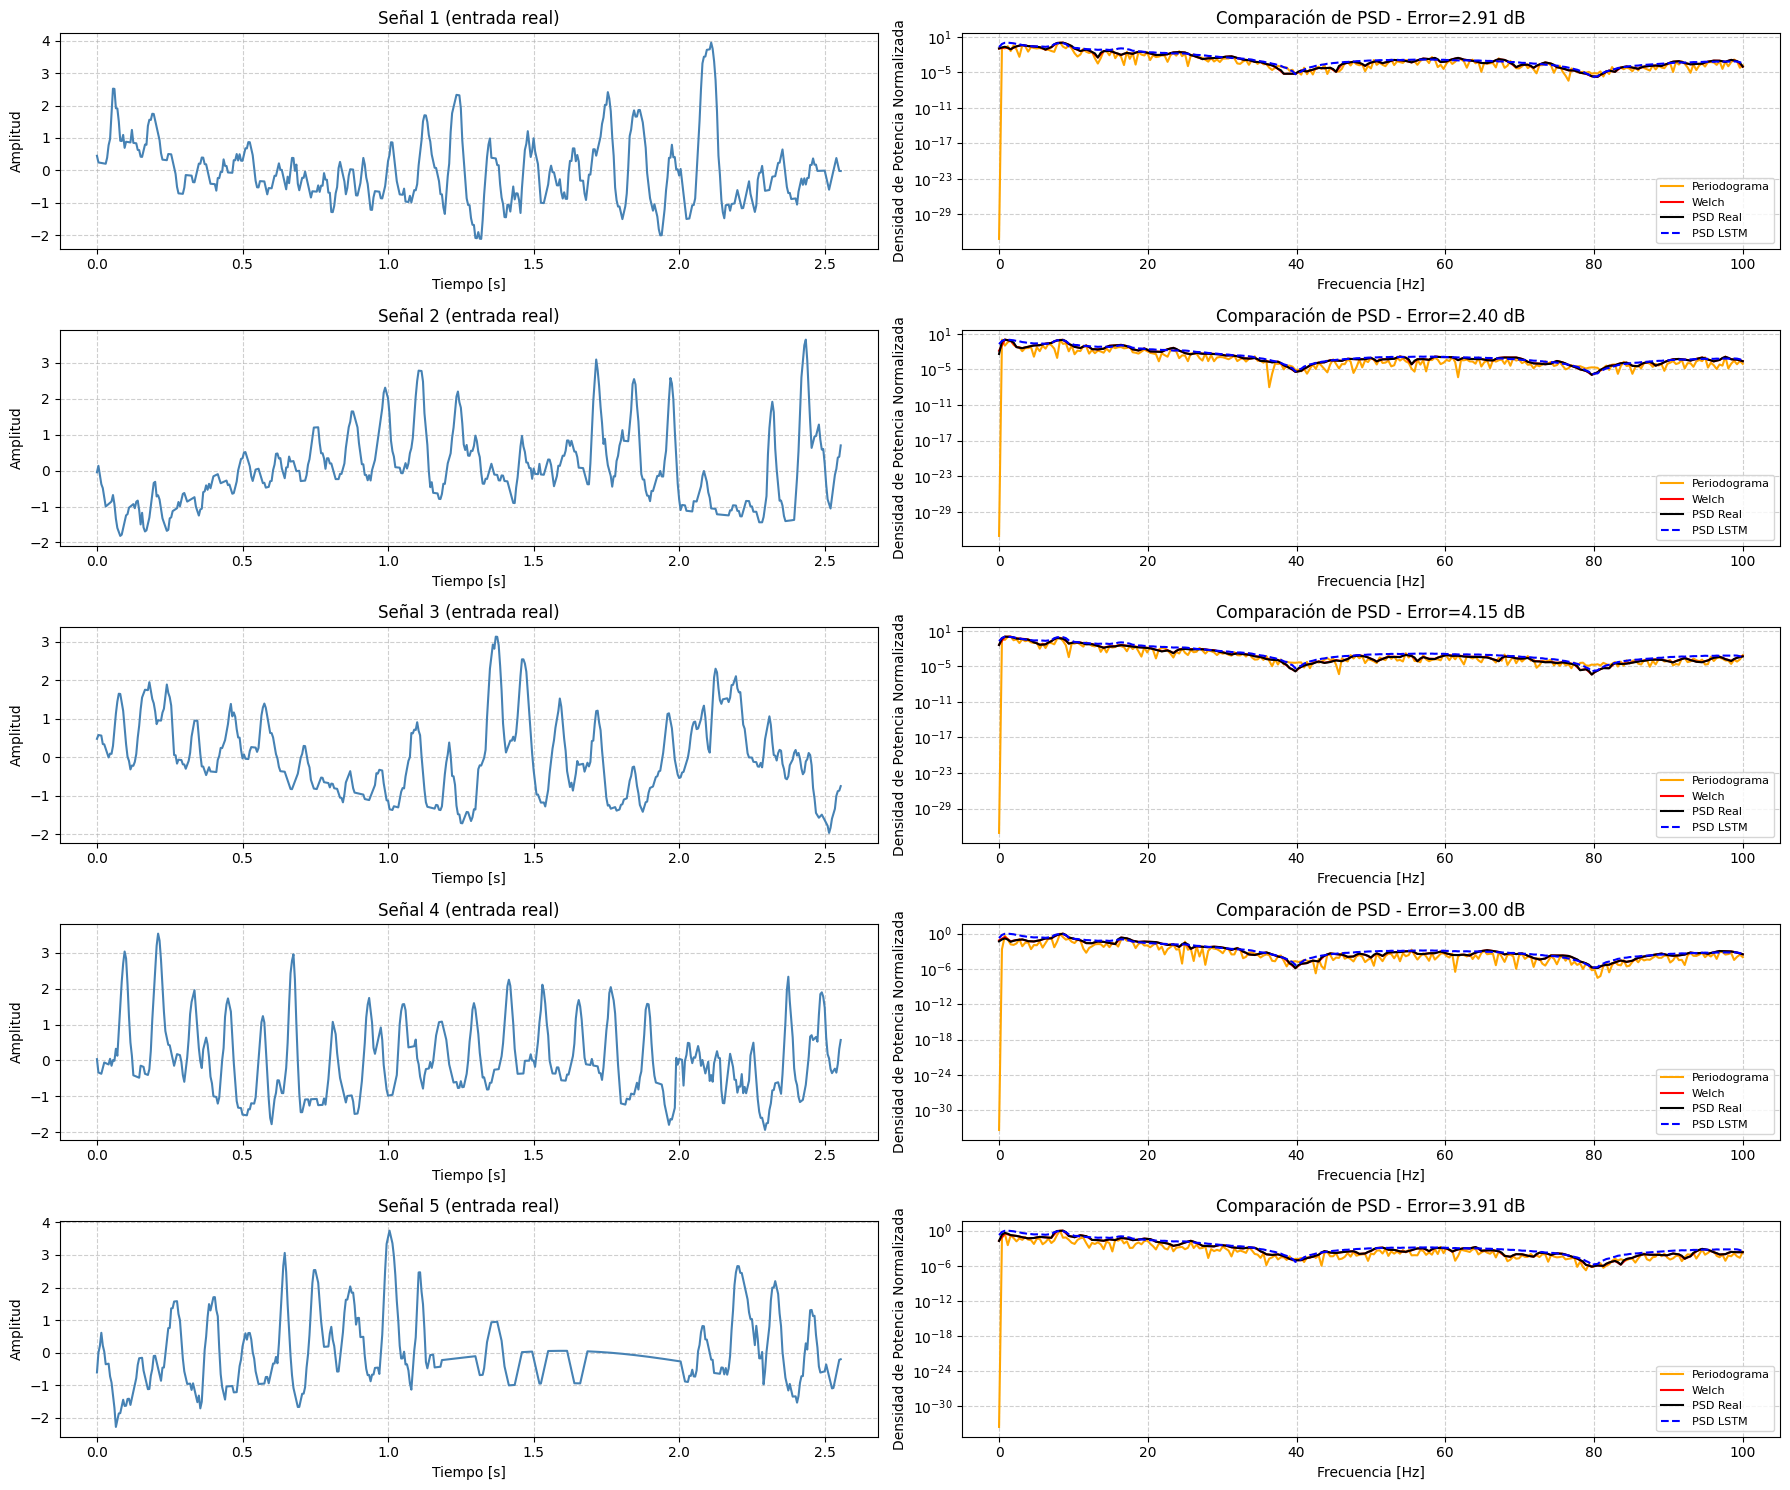

📈 Error espectral promedio (en dB): 3.276


In [8]:
# ===== Celda 6: Evaluación múltiple (Welch, Periodograma y error espectral promedio en dB) =====
from sklearn.metrics import mean_squared_error

model.eval()
num_examples = 5
indices = np.random.choice(len(preds_lin), num_examples, replace=False)
errors_db = []

plt.figure(figsize=(18, num_examples * 3))

for i, idx in enumerate(indices):
    # Señal de entrada original
    signal = inputs[idx].squeeze()
    signal = detrend(signal)
    signal = highpass_filter(signal, FS)
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-12)

    # PSDs reales y estimadas
    f_w, Pxx_w = welch(signal, fs=FS, nperseg=256)
    f_p, Pxx_p = periodogram(signal, fs=FS)
    f_model = np.linspace(0, FS/2, preds_lin.shape[1])

    psd_true = trues_lin[idx]
    psd_pred = preds_lin[idx]

    # Normalización espectral para comparar en escala relativa
    def norm(x): return x / (np.max(x) + 1e-12)
    psd_true_n = norm(psd_true)
    psd_pred_n = norm(psd_pred)

    # Error espectral medio en dB
    err_db = 10 * np.mean(np.abs(np.log10(psd_true_n + 1e-12) - np.log10(psd_pred_n + 1e-12)))
    errors_db.append(err_db)

    # ---- Gráficas ----
    plt.subplot(num_examples, 2, 2*i+1)
    plt.plot(np.arange(SEQ_LENGTH)/FS, signal, color="steelblue")
    plt.title(f"Señal {i+1} (entrada real)", fontsize=12)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.subplot(num_examples, 2, 2*i+2)
    plt.semilogy(f_p, norm(Pxx_p), label="Periodograma", color="orange")
    plt.semilogy(f_w, norm(Pxx_w), label="Welch", color="red")
    plt.semilogy(f_model, psd_true_n, label="PSD Real", color="black")
    plt.semilogy(f_model, psd_pred_n, label="PSD LSTM", linestyle="--", color="blue")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Densidad de Potencia Normalizada")
    plt.title(f"Comparación de PSD - Error={err_db:.2f} dB", fontsize=12)
    plt.legend(fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"📈 Error espectral promedio (en dB): {np.mean(errors_db):.3f}")


#**Celda 7 — Guardado y carga del modelo entrenado (LSTM)**
| Paso                 | Descripción                                                                           |
| -------------------- | ------------------------------------------------------------------------------------- |
| 💾 **Guardado**      | Guarda los pesos del modelo (`state_dict`) en un archivo `.pth` compacto.             |
| 🔄 **Carga**         | Crea un nuevo objeto `LSTM_PSD` con la misma arquitectura y le carga los pesos.       |
| 🧠 **Verificación**  | Comprueba que el modelo cargado puede generar predicciones sin errores.               |
| 📊 **Visualización** | Grafica una PSD real vs. la PSD estimada por el modelo cargado (verificación rápida). |


💾 Modelo LSTM guardado correctamente en: lstm_psd_model.pth
✅ Modelo cargado correctamente y listo para inferencia.
Predicción de prueba exitosa. Forma de salida: (64, 257)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


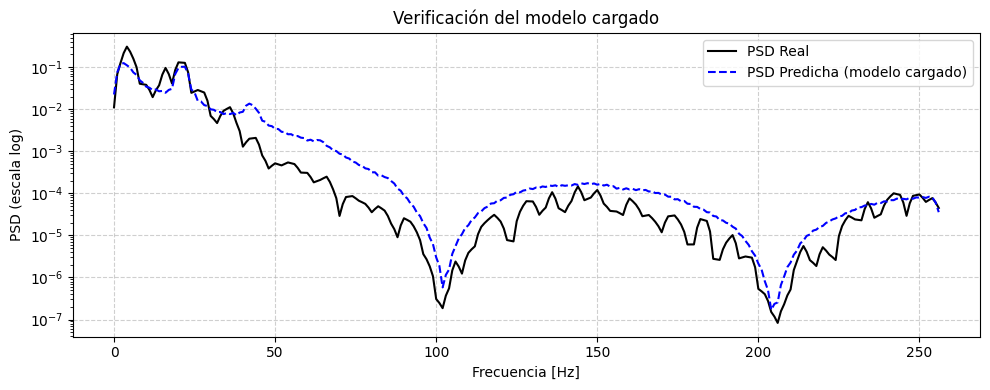

In [9]:
# ===== Celda 7: Guardado y carga del modelo entrenado (LSTM) =====

# --- Guardar el modelo entrenado ---
save_path = "lstm_psd_model.pth"
torch.save(model.state_dict(), save_path)
print(f"💾 Modelo LSTM guardado correctamente en: {save_path}")

# --- Cargar el modelo para inferencia ---
loaded_model = LSTM_PSD(input_size=1, hidden_size=64, num_layers=1,
                        output_size=PSD_LEN, dropout=0.1, bidir=False).to(device)

loaded_model.load_state_dict(torch.load(save_path, map_location=device))
loaded_model.eval()
print("✅ Modelo cargado correctamente y listo para inferencia.")

# --- Prueba rápida de predicción con una señal del test set ---
with torch.no_grad():
    xb, yb = next(iter(test_loader))
    xb = xb.to(device)
    y_pred = loaded_model(xb).cpu().numpy()
    print(f"Predicción de prueba exitosa. Forma de salida: {y_pred.shape}")

# --- Visualización rápida de ejemplo ---
idx = np.random.randint(0, len(y_pred))
plt.figure(figsize=(10, 4))
plt.semilogy(np.exp(yb[idx].numpy()), label="PSD Real", color="black")
plt.semilogy(np.exp(y_pred[idx]), label="PSD Predicha (modelo cargado)", linestyle="--", color="blue")
plt.title("Verificación del modelo cargado")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD (escala log)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
